<a href="https://colab.research.google.com/github/yogeshne9i/Stock_Price_Analysis_Major/blob/main/02_Linear_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
df = pd.read_csv("US_Stock_Data.csv")
df.head()


,Unnamed: 0,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,...,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
0,0,2/2/2024,2.079,NaN,72.28,NaN,3.8215,NaN,"43,194.70",42650,...,"5,89,498",10580,564.64,4030000,171.81,117220000,474.99,84710000,"2,053.70",NaN
1,1,1/2/2024,2.050,161340.0,73.82,577940.0,3.8535,NaN,"43,081.40",47690,...,"5,81,600",9780,567.51,3150000,159.28,66360000,394.78,25140000,"2,071.10",260920.0
2,2,31-01-2024,2.100,142860.0,75.85,344490.0,3.9060,NaN,"42,580.50",56480,...,"5,78,020",9720,564.11,4830000,155.20,49690000,390.14,20010000,"2,067.40",238370.0
3,3,30-01-2024,2.077,139750.0,77.82,347240.0,3.9110,NaN,"42,946.20",55130,...,"5,84,680",9750,562.85,6120000,159.00,42290000,400.06,18610000,"2,050.90",214590.0
4,4,29-01-2024,2.490,3590.0,76.78,331930.0,3.8790,NaN,"43,299.80",45230,...,"5,78,800",13850,575.79,6880000,161.26,42840000,401.02,17790000,"2,034.90",1780.0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1013 entries, 0 to 1012
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1013 non-null   int64  
 1   Date               1013 non-null   object 
 2   Natural_Gas_Price  1013 non-null   float64
 3   Natural_Gas_Vol.   1009 non-null   float64
 4   Crude_oil_Price    1013 non-null   float64
 5   Crude_oil_Vol.     990 non-null    float64
 6   Copper_Price       1013 non-null   float64
 7   Copper_Vol.        976 non-null    float64
 8   Bitcoin_Price      1013 non-null   object 
 9   Bitcoin_Vol.       1013 non-null   int64  
 10  Platinum_Price     1013 non-null   object 
 11  Platinum_Vol.      636 non-null    float64
 12  Ethereum_Price     1013 non-null   object 
 13  Ethereum_Vol.      1013 non-null   int64  
 14  S&P_500_Price      1013 non-null   object 
 15  Nasdaq_100_Price   1013 non-null   object 
 16  Nasdaq_100_Vol.    1012 

In [ ]:
df.describe()


,Unnamed: 0,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Vol.,Platinum_Vol.,Ethereum_Vol.,...,Nvidia_Price,Nvidia_Vol.,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Vol.
count,1013.000000,1013.000000,1009.000000,1013.000000,9.900000e+02,1013.000000,976.000000,1.013000e+03,636.000000,1.013000e+03,...,1013.000000,1.013000e+03,1013.000000,1013.000000,1.013000e+03,1013.000000,1.013000e+03,1013.000000,1.013000e+03,1011.000000
mean,506.000000,3.726667,129091.932607,69.853475,3.571739e+05,3.726843,37606.752049,4.924137e+07,9082.515723,1.958002e+07,...,219.738065,4.629821e+07,2918.400790,422.035479,7.012043e+06,137.426209,7.452566e+07,252.151046,2.504895e+07,189442.393670
std,292.572213,1.943030,64035.426727,21.986697,1.864309e+05,0.646524,39192.315092,3.251389e+08,8876.538587,1.469409e+08,...,128.668703,1.878815e+07,2715.637488,119.765870,6.788094e+06,27.321896,3.376809e+07,72.949246,1.635122e+07,104007.872337
min,0.000000,1.482000,1200.000000,-37.630000,1.702000e+04,2.100500,10.000000,2.600000e+02,0.000000,7.518000e+04,...,49.100000,9.790000e+06,120.000000,166.370000,1.140000e+06,81.820000,2.162000e+07,88.910000,5.470000e+06,0.000000
25%,253.000000,2.447000,88680.000000,54.760000,2.751800e+05,3.408000,380.000000,7.142000e+04,1120.000000,5.272300e+05,...,131.980000,3.348000e+07,760.000000,338.630000,3.780000e+06,114.770000,5.192000e+07,195.210000,1.612000e+07,142985.000000
50%,506.000000,2.880000,125980.000000,72.910000,3.450350e+05,3.800500,31635.000000,1.288800e+05,6070.000000,9.665800e+05,...,179.130000,4.368000e+07,2040.000000,431.600000,5.380000e+06,142.300000,6.515000e+07,262.010000,2.107000e+07,181200.000000
75%,759.000000,4.805000,164810.000000,82.810000,4.269225e+05,4.251500,70982.500000,3.860000e+05,15287.500000,3.670000e+06,...,272.470000,5.640000e+07,4090.000000,509.640000,7.890000e+06,161.060000,8.683000e+07,313.190000,2.903000e+07,231500.000000
max,1012.000000,9.647000,381970.000000,123.700000,1.770000e+06,4.937500,176040.000000,4.470000e+09,42830.000000,1.790000e+09,...,661.600000,1.534600e+08,13850.000000,691.690000,1.333900e+08,186.570000,3.113500e+08,474.990000,2.304100e+08,813410.000000


In [ ]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed')
df = df.sort_values('Date')

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

df.isnull().sum()


,0
Date,0
Natural_Gas_Price,0
Natural_Gas_Vol.,0
Crude_oil_Price,0
Crude_oil_Vol.,0
Copper_Price,0
Copper_Vol.,0
Bitcoin_Price,0
Bitcoin_Vol.,0
Platinum_Price,0


In [ ]:
# Create lag feature
df['Netflix_Price_Lag1'] = df['Netflix_Price'].shift(1)

# Drop first row (NaN due to lag)
df.dropna(inplace=True)

df.head()


,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,Platinum_Price,...,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.,Netflix_Price_Lag1
867,2020-08-03,2.101,381970.0,41.01,338330.0,2.9205,40.0,"11,224.40",470240,938,...,470,498.62,5880000,155.59,101490000,251.96,23130000,"1,986.30",178750.0,488.88
866,2020-08-04,2.193,230890.0,41.70,451580.0,2.9030,50.0,"11,184.70",485790,961,...,270,509.64,5610000,156.94,93890000,249.83,17180000,"2,021.00",274420.0,498.62
865,2020-08-05,2.191,182430.0,42.19,491270.0,2.9250,30.0,"11,735.10",570830,994.9,...,560,502.11,4310000,160.25,78600000,249.12,13090000,"2,049.30",366380.0,509.64
864,2020-08-06,2.165,161990.0,41.95,359610.0,2.9190,290.0,"11,757.10",554850,"1,020.80",...,440,509.08,3730000,161.25,78810000,265.28,45240000,"2,069.40",312760.0,502.11
863,2020-08-07,2.238,206250.0,41.22,399000.0,2.8020,310.0,"11,592.00",517000,977.4,...,440,494.73,5910000,158.37,78720000,268.44,72770000,"2,028.00",398130.0,509.08


In [ ]:
features = [
    'Crude_oil_Price',
    'Natural_Gas_Price',
    'S&P_500_Price',
    'Nasdaq_100_Price',
    'Netflix_Price_Lag1'
]

X = df[features]
y = df['Netflix_Price']

X.head(), y.head()


(     Crude_oil_Price  Natural_Gas_Price S&P_500_Price Nasdaq_100_Price  \
 867            41.01              2.101      3,294.61        11,055.08   
 866            41.70              2.193      3,306.51        11,096.54   
 865            42.19              2.191      3,327.77        11,125.44   
 864            41.95              2.165      3,349.16        11,267.08   
 863            41.22              2.238      3,351.28        11,139.39   
 
      Netflix_Price_Lag1  
 867              488.88  
 866              498.62  
 865              509.64  
 864              502.11  
 863              509.08  ,
 867    498.62
 866    509.64
 865    502.11
 864    509.08
 863    494.73
 Name: Netflix_Price, dtype: float64)

In [ ]:
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]


In [ ]:
#Train Linear Regression Model

In [ ]:
for col in ['S&P_500_Price', 'Nasdaq_100_Price']:
    X_train[col] = X_train[col].astype(str).str.replace(',', '', regex=False).astype(float)
    X_test[col] = X_test[col].astype(str).str.replace(',', '', regex=False).astype(float)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Intercept:", lr_model.intercept_)

Intercept: 26.13900727387272


/tmp/ipython-input-2688738848.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype(str).str.replace(',', '', regex=False).astype(float)
/tmp/ipython-input-2688738848.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = X_test[col].astype(str).str.replace(',', '', regex=False).astype(float)
/tmp/ipython-input-2688738848.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

In [ ]:
# Coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_
})

coef_df


,Feature,Coefficient
0,Crude_oil_Price,-0.042749
1,Natural_Gas_Price,-0.616489
2,S&P_500_Price,-0.050960
3,Nasdaq_100_Price,0.016241
4,Netflix_Price_Lag1,0.928977


In [ ]:
y_pred = lr_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)


Linear Regression Performance:
MAE : 9.942187640773376
MSE : 150.7534435993604
RMSE: 12.278169391214652
R²  : 0.9805025626804329


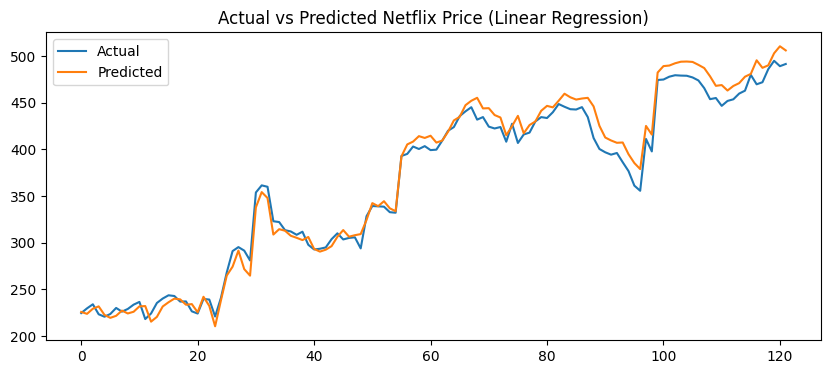

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Netflix Price (Linear Regression)")
plt.show()


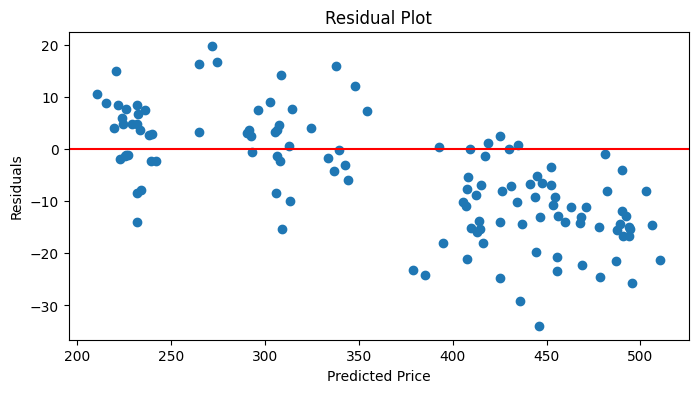

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,4))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()
